In [51]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [52]:
df = pd.read_csv("qatar_rental_properties.csv")

In [53]:
df.head(5)

,title,price,location,bedrooms,bathrooms,area,property_type,listing_url
0,BRAND NEW 2BDR + MAID | FURNISHED | BILLS INCL...,8500,"Dara, Fox Hills, Lusail",8.0,2.0,120,Apartment,https://www.propertyfinder.qa/en/plp/rent/apar...
1,"2 BHK IN WAKRA,NO COMMISSION,AUGUST FREE",3800,"Al Wakra Hotel, Al Wakra, Al Wakrah, Al Wakra",2.0,2.0,75,Apartment,https://www.propertyfinder.qa/en/plp/rent/apar...
2,DEAL OF THE MONTH | FURNISHED 2BR | AL WAAB,6200,"Janayin Al Waab, Al Waab, Doha",2.0,2.0,127,Apartment,https://www.propertyfinder.qa/en/plp/rent/apar...
3,BILLS INCLUDED | NEW 2BR | HOTEL FACILITIES,10154,"West Bay Villas, West Bay, West Bay, Doha",2.0,2.0,137,Apartment,https://www.propertyfinder.qa/en/plp/rent/apar...
4,BILLS INCLUDED | BRAND NEW | HOTEL FACILITIES,7846,"Burj Doha, West Bay, West Bay, Doha",1.0,1.0,84,Apartment,https://www.propertyfinder.qa/en/plp/rent/apar...


In [54]:
df.shape

(19118, 8)

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19118 entries, 0 to 19117
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          19118 non-null  str    
 1   price          19118 non-null  int64  
 2   location       19118 non-null  str    
 3   bedrooms       19103 non-null  float64
 4   bathrooms      19106 non-null  float64
 5   area           19118 non-null  int64  
 6   property_type  19118 non-null  str    
 7   listing_url    19117 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 4.9 MB


In [56]:
df.isnull().sum()

title             0
price             0
location          0
bedrooms         15
bathrooms        12
area              0
property_type     0
listing_url       1
dtype: int64

In [57]:
df = df.dropna()

In [58]:
# remove unused columns
df = df.drop(columns=["title", "listing_url"])

# clean location (extract last part)
df["location"] = df["location"].apply(lambda x: x.split(",")[-1].strip())

# group rare locations
rare_locations = df["location"].value_counts()[df["location"].value_counts() < 100].index
df["location"] = df["location"].replace(rare_locations, "Other")

In [59]:
df["area_per_room"] = df["area"] / df["bedrooms"]

In [60]:
df = df[df["bedrooms"] <= 6]
df = df[df["area"] <= 500]

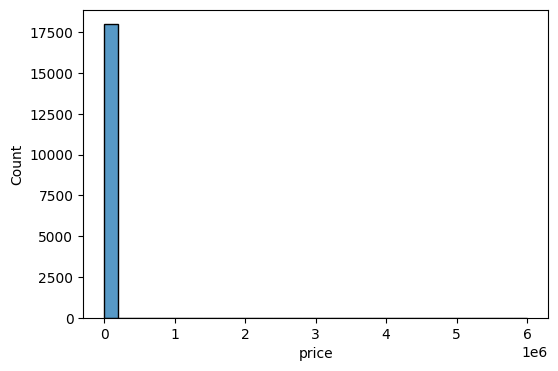

In [62]:
plt.figure(figsize = (6,4))
sns.histplot(df["price"],bins=30)
plt.show()

In [63]:
df["log_price"] = np.log1p(df["price"])

In [64]:
x = df.drop(columns = ["price", "log_price"])
y = df["log_price"]

In [65]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y , test_size=0.2, random_state= 42)

In [66]:
#Feature types

num_features = ["bedrooms", "bathrooms", "area"]
cat_features = ["location", "property_type"]

In [67]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


#preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", HistGradientBoostingRegressor(max_depth=6))
    ]
)

In [69]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE", mae)
print("RMSE", rmse)
print("R2 Score", r2)

MAE 0.20121238709196185
RMSE 0.2664380805067551
R2 Score 0.6443398613657123


In [71]:
y_pred_price = np.expm1(y_pred)
y_test_price = np.expm1(y_test)

mae_real = mean_absolute_error(y_test_price, y_pred_price)

print("Average Rent Error (QAR):", mae_real)

Average Rent Error (QAR): 1962.7653542592013


In [ ]:
import pickle

with open("rent_model.pkl", "wb") as f:
    pickle.dump(model, f)